<a href="https://colab.research.google.com/github/MelB18/EasyQuanten/blob/main/Grover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grovers Algorithmus

In [8]:
%pip install qiskit qiskit-aer matplotlib

## Grover für 2 Qubits

2 Qubits => eine Interation

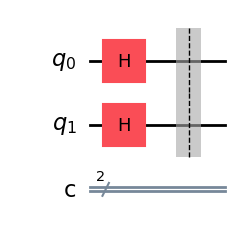

In [41]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler
import matplotlib.pyplot as plt

# 1. Initialisierung: 2 Qubits + 2 klassische Bits
qc = QuantumCircuit(2, 2)

# In gleichmäßige Überlagerung bringen
qc.h([0, 1])
qc.barrier()

qc.draw(output='mpl')

### Orakel

Eins auswählen

In [42]:
# 2. DAS ORAKEL (für den Zustand |11>)
# Ein CZ-Gatter flippt die Phase von |11>
qc.cz(0, 1)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

In [31]:
# Orakel für 00
# Beide Qubits müssen vor/nach dem CZ geflippt werden
qc.x([0, 1])
qc.cz(0, 1)
qc.x([0, 1])
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

In [36]:
# Orakel für 01
qc.x(1)
qc.cz(0, 1)
qc.x(1)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

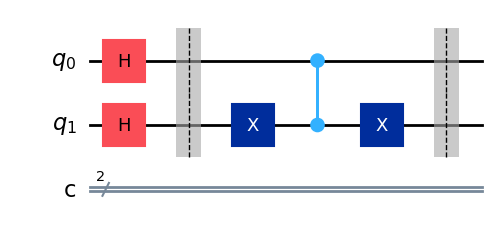

In [37]:
qc.draw(output='mpl')

### Diffuser

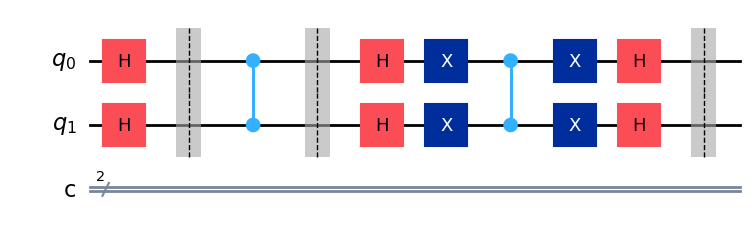

In [43]:
# 3. DER DIFFUSIONS-OPERATOR (Jetzt explizit für beide Qubits)
qc.h([0, 1])  # H-Gatter auf beide
qc.x([0, 1])  # X-Gatter auf beide

# Controlled-Z im Diffusor
qc.cz(0, 1)

qc.x([0, 1])  # X-Gatter zurückrechnen
qc.h([0, 1])  # H-Gatter zurückrechnen
qc.barrier()

qc.draw(output='mpl')

### Ausführung

In [44]:
qc.measure([0, 1], [0, 1])

# --- SCHALTKREIS AUSFÜHREN ---
simulator = AerSimulator()
sampler = StatevectorSampler()

# Job mit 1024 Durchläufen starten
job = sampler.run([(qc)], shots=1024)
result = job.result()

# Ergebnisse auslesen
counts = result[0].data.c.get_counts()
print("Messergebnisse:", counts)

# Histogramm anzeigen
plot_histogram(counts)
plt.show()

Messergebnisse: {'11': 1024}


## Grover für 3 Qubits

3 Qubits => 2 Interationen

In [69]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# 1. Initialisierung: 3 Qubits + 3 klassische Bits für die Messung
grover_circuit = QuantumCircuit(3, 3)

# Gleichmäßige Überlagerung herstellen
grover_circuit.h([0, 1, 2])
grover_circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

### Iteration

zur Verbesserung des Messergebnis Orakel und Diffuser jeweils zweimal ausführen

Iteration 1: Orakel => Diffuser
Iteration 2: Orakel => Diffuser

In [ ]:
# 2. DAS ORAKEL (für den Zustand |111>)
# Ein MCZ-Gatter flippt die Phase genau dann, wenn alle Qubits 1 sind.
# In Qiskit steuern wir ein Z-Gatter mit zwei Kontrollbits an:
grover_circuit.ccz(0, 1, 2)
grover_circuit.barrier()

In [72]:
## Orakel 101
grover_circuit.x(1)         # Qubit 1 flippen
grover_circuit.ccz(0, 1, 2) # MCZ Gatter
grover_circuit.x(1)         # Qubit 1 zurückflippen

In [73]:


# 3. DER DIFFUSIONS-OPERATOR (Inversion um den Mittelwert)
# Schritt A: Transformation mit H-Gattern
grover_circuit.h([0, 1, 2])
# Schritt B: Alle Zustände außer |000> mit X-Gattern umkehren
grover_circuit.x([0, 1, 2])

# Schritt C: Multi-Controlled-Z auf die transformierten Zustände
grover_circuit.ccz(0, 1, 2)

# Schritt D: X- und H-Gatter zurückrechnen
grover_circuit.x([0, 1, 2])
grover_circuit.h([0, 1, 2])
grover_circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

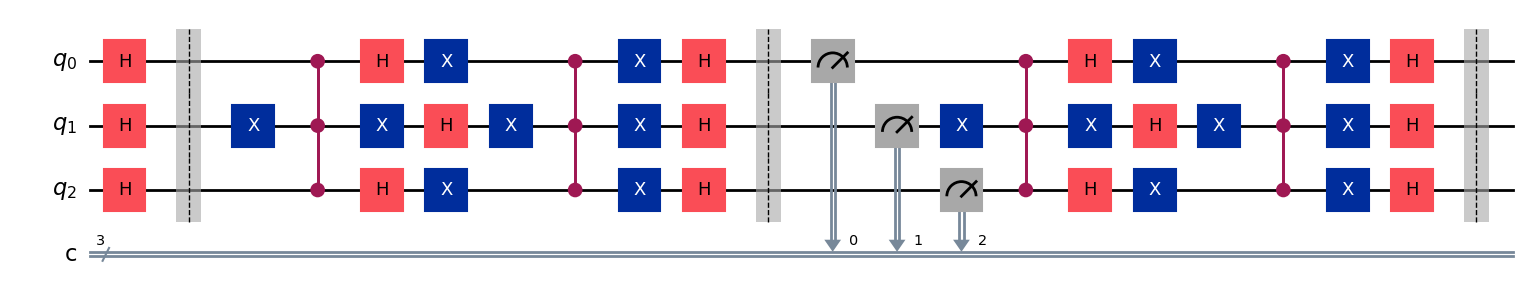

In [67]:
grover_circuit.draw(output='mpl')

### Ausführung

Messergebnisse: {'101': 963, '001': 8, '011': 12, '000': 9, '110': 8, '100': 4, '111': 11, '010': 9}


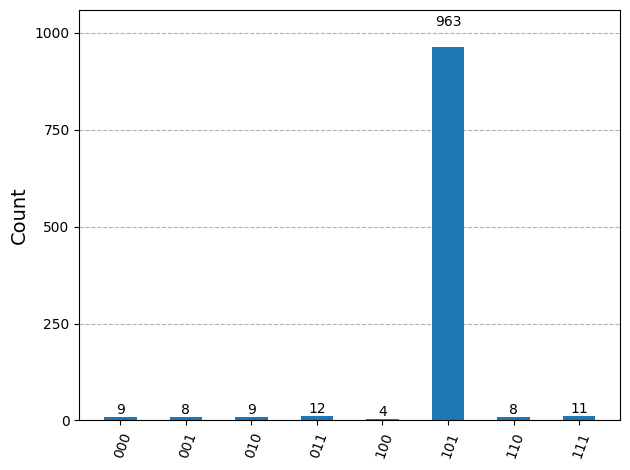

In [74]:
# 4. MESSUNG
grover_circuit.measure([0, 1, 2], [0, 1, 2])

# --- SCHALTKREIS AUSFÜHREN ---
simulator = AerSimulator()
# Vorbereitung für den modernen Sampler
from qiskit.primitives import StatevectorSampler
sampler = StatevectorSampler()

# Job ausführen (1024 Durchläufe)
job = sampler.run([(grover_circuit)], shots=1024)
result = job.result()[0]

# Ergebnisse auslesen
counts = result.data.c.get_counts()
print("Messergebnisse:", counts)

# Histogramm anzeigen
plot_histogram(counts)


## Grover für Tic Tac Toe

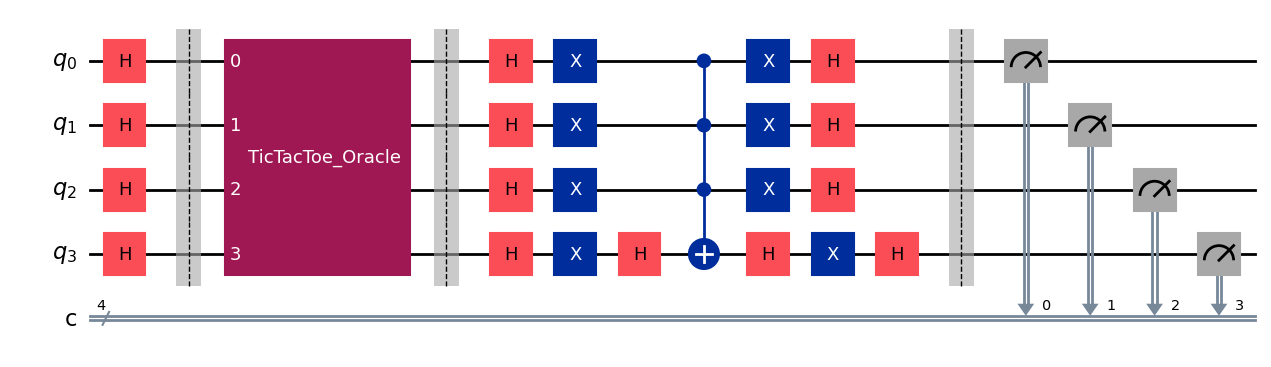

Messergebnisse (Feld 4 sollte 0100 sein): {'1001': 40, '1100': 33, '0010': 36, '0100': 489, '1110': 39, '1101': 27, '0110': 34, '0101': 35, '0111': 41, '1111': 30, '0011': 42, '1000': 43, '0000': 34, '1011': 37, '1010': 34, '0001': 30}


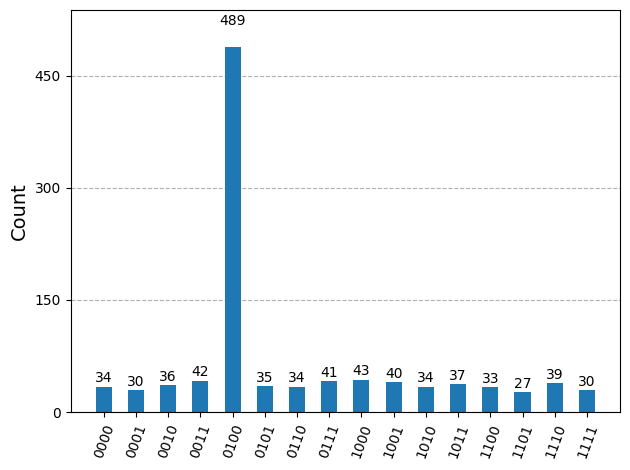

In [108]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Operator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

def create_tic_tac_toe_oracle():
    """
    Erstellt ein Orakel für Feld 4.
    """
    matrix = np.eye(16)
    optimal_move = 4
    matrix[optimal_move, optimal_move] = -1
    return Operator(matrix)

def grover_tic_tac_toe():
    # 4 Qubits und 4 klassische Bits
    qc = QuantumCircuit(4, 4)

    # 1. Schritt: Superposition
    qc.h(range(4))
    qc.barrier()

    # 2. Schritt: Orakel
    oracle_op = create_tic_tac_toe_oracle()
    qc.unitary(oracle_op, range(4), label="TicTacToe_Oracle")
    qc.barrier()

    # 3. Schritt: Diffusor
    qc.h(range(4))
    qc.x(range(4))
    qc.h(3)
    qc.mcx([0, 1, 2], 3)
    qc.h(3)
    qc.x(range(4))
    qc.h(range(4))
    qc.barrier()

    # 4. Schritt: Gezielte Messung in das Register 'c'
    qc.measure(range(4), range(4))

    return qc

# Schaltung aufbauen und zeichnen
circuit = grover_tic_tac_toe()
display(circuit.draw(output='mpl'))

# --- SCHALTKREIS AUSFÜHREN ---
sampler = StatevectorSampler()
job = sampler.run([circuit], shots=1024)
result = job.result()[0]

# Ergebnisse aus dem klassischen Register 'c' auslesen
counts = result.data.c.get_counts()
print("Messergebnisse (Feld 4 sollte 0100 sein):", counts)

# Histogramm anzeigen
plot_histogram(counts)


Im Histogramm und an den Messergebnissen sieht man, dass der Zustand 0100 (was binär für die Zahl 4 steht) die höchste Wahrscheinlichkeit hat. Das bestätigt, dass Grovers Algorithmus das im Orakel markierte Feld 4 erfolgreich gefunden hat.

Aktuelles Spielfeld (0=Leer, 1=X, 2=O):
[[1 2 1]
 [0 1 2]
 [0 2 0]]
----------------------------------------
[Quanten-Orakel] Gewinnbringender Zug auf Feld 6 erkannt!
[Quanten-Orakel] Gewinnbringender Zug auf Feld 8 erkannt!
Messergebnisse: {'0110': 388, '1110': 21, '1000': 394, '1001': 23, '1101': 18, '0100': 13, '0000': 20, '1011': 18, '0010': 14, '0111': 15, '1111': 19, '0101': 9, '1010': 21, '0011': 24, '0001': 13, '1100': 14}
----------------------------------------
Die Quanten-Strategie empfiehlt Feld-Index: 8 (Konfidenz: 38.48%)


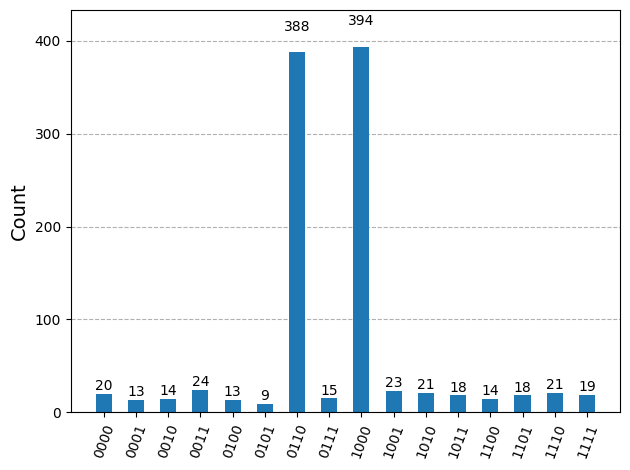

In [120]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Operator

# Gewinnkombinationen auf einem 3x3 Feld (Indizes 0 bis 8)
WIN_COMBINATIONS = [
    [0, 1, 2], [3, 4, 5], [6, 7, 8],  # Horizontal
    [0, 3, 6], [1, 4, 7], [2, 5, 8],  # Vertikal
    [0, 4, 8], [2, 4, 6]              # Diagonal
]

def find_winning_move_oracle(board, player=1):
    """
    Erstellt eine unitäre Matrix (Orakel), die den quantenmechanischen Zustand
    eines Zuges markiert, der sofort zum Sieg führt.
    """
    matrix = np.eye(16)
    winning_move_found = False

    for move in range(9):
        if board[move] == 0:
            temp_board = list(board)
            temp_board[move] = player
            is_win = any(all(temp_board[idx] == player for idx in combo) for combo in WIN_COMBINATIONS)

            if is_win:
                matrix[move, move] = -1
                winning_move_found = True
                print(f"[Quanten-Orakel] Gewinnbringender Zug auf Feld {move} erkannt!")

    if not winning_move_found:
        for move in range(9):
            if board[move] == 0:
                matrix[move, move] = -1

    return Operator(matrix)

def run_quantum_strategy(board):
    qc = QuantumCircuit(4)
    qc.h(range(4))
    qc.barrier()

    oracle_op = find_winning_move_oracle(board, player=1)
    qc.unitary(oracle_op, range(4), label="Dynamic_Oracle")
    qc.barrier()

    qc.h(range(4))
    qc.x(range(4))
    qc.h(3)
    qc.mcx(list(range(3)), 3)
    qc.h(3)
    qc.x(range(4))
    qc.h(range(4))

    qc.measure_all()

    # Verwendung von StatevectorSampler (V2)
    sampler = StatevectorSampler()
    job = sampler.run([qc], shots=1024)
    result = job.result()[0]

    # Ergebnisse aus dem standardmäßigen Messregister 'meas' auslesen
    counts = result.data.meas.get_counts()

    print("Messergebnisse:", counts)

    # In Integers umwandeln und nach Häufigkeit sortieren
    sorted_moves = sorted(counts.items(), key=lambda item: item[1], reverse=True)

    for move_str, count in sorted_moves:
        move = int(move_str, 2)
        if move < 9 and board[move] == 0:
            return move, count / 1024, counts

    return None, 0, 0

current_board = [
    1, 2, 1,
    0, 1, 2,
    0, 2, 0
]

print("Aktuelles Spielfeld (0=Leer, 1=X, 2=O):")
print(np.array(current_board).reshape(3, 3))
print("-" * 40)

best_move, confidence, all_counts = run_quantum_strategy(current_board)

print("-" * 40)
print(f"Die Quanten-Strategie empfiehlt Feld-Index: {best_move} (Konfidenz: {confidence*100:.2f}%)")

plot_histogram(all_counts)